In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
import shap


In [2]:
df = pd.read_json("../data/supervise_myth_clusters.json", lines=True)
df_tropes = pd.read_json("../data/binary_myth_tropes.json", orient="records", lines=True)
print(df.columns)

Index(['id', 'text', 'type', 'source', 'imdb_title', 'imdb_year',
       'imdb_genres', 'inferred_media_type', 'combined_text',
       'has_semantic_match', 'has_lexical_match',
       'has_sentence_myth_trope_hit', 'max_trope_similarity', 'myth_hit_count',
       'myth_theme', 'cluster', 'has_myth_hit', 'has_myth_trope_hit',
       'agglo_cluster'],
      dtype='object')


In [3]:
X = df_tropes.drop(columns=['cluster'])
y = df['cluster']

In [4]:
ovr_rf = OneVsRestClassifier(
    RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(ovr_rf, X, y, cv=cv, scoring='f1_macro')
print(f"Cross-validated Macro F1 Score: {np.mean(scores):.4f} ± {np.std(scores):.4f}")


Cross-validated Macro F1 Score: 0.9940 ± 0.0024


In [6]:
ovr_rf.fit(X, y)

,estimator,RandomForestC...ndom_state=42)
,n_jobs,None
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None


In [7]:
y_pred = ovr_rf.predict(X)
print(classification_report(y, y_pred))
print(confusion_matrix(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       609
           1       1.00      0.99      1.00       794
           2       0.99      1.00      0.99       528
           3       1.00      1.00      1.00       344

    accuracy                           1.00      2275
   macro avg       1.00      1.00      1.00      2275
weighted avg       1.00      1.00      1.00      2275

[[609   0   0   0]
 [  0 788   6   0]
 [  0   0 528   0]
 [  0   0   0 344]]


In [ ]:
feature_names = X.columns

for idx, estimator in enumerate(ovr_rf.estimators_):
    importances = estimator.feature_importances_
    top_indices = np.argsort(importances)[::-1][:10]
    print(f"\nTop features for Cluster {idx}:")
    for i in top_indices:
        print(f"{feature_names[i]}: {importances[i]:.4f}")

# .... of course it's perfect, you're predicting on the same features you clustered on :facepalm:


Top features for Cluster 0:
Reincarnation: 0.4211
BigBad: 0.2633
TheTrickster: 0.0582
Animal_Beast: 0.0561
DragonsAreDivine: 0.0302
Trickster God: 0.0164
Satan: 0.0131
WarGod: 0.0120
WhiteMage: 0.0111
TheChosenOne: 0.0109

Top features for Cluster 1:
TheTrickster: 0.3249
Animal_Beast: 0.3051
Reincarnation: 0.1423
BigBad: 0.0582
DarkestHour: 0.0319
TheChosenOne: 0.0262
DealWithTheDevil: 0.0140
DragonsAreDivine: 0.0130
SpiritAdvisor: 0.0109
AntiHero: 0.0083

Top features for Cluster 2:
Reincarnation: 0.5347
Animal_Beast: 0.1445
TheTrickster: 0.1305
DarkestHour: 0.0261
BigBad: 0.0242
TheChosenOne: 0.0149
GrimReaper: 0.0145
Satan: 0.0116
Trickster God: 0.0085
SpiritAdvisor: 0.0082

Top features for Cluster 3:
BigBad: 0.6052
Reincarnation: 0.2371
AntiHero: 0.0155
Animal_Beast: 0.0144
TheTrickster: 0.0143
DealWithTheDevil: 0.0103
DarkestHour: 0.0090
SpiritAdvisor: 0.0085
Satan: 0.0084
DragonsAreDivine: 0.0080


In [ ]:
y = df['cluster']

#df['imdb_genres_str'] = df['imdb_genres'].apply(lambda x: ', '.join(x) if isinstance(x, list) else str(x))
df['imdb_genres_clean'] = df['imdb_genres'].apply(lambda x: x if isinstance(x, list) else [])

X_diff = df.drop(columns=['cluster', 'agglo_cluster', 'myth_theme', 'id', 'text', 'combined_text', 'imdb_title', 'imdb_genres'])


mlb = MultiLabelBinarizer()
genre_dummies = pd.DataFrame(mlb.fit_transform(df['imdb_genres_clean']), 
                             columns=[f'genre_{g}' for g in mlb.classes_],
                             index=df.index)


X_diff = X_diff.drop(columns=['imdb_genres_str', 'imdb_genres_clean'], errors='ignore')


X_diff = pd.concat([X_diff, genre_dummies], axis=1)
X_diff.dtypes


type                            object
source                          object
imdb_year                      float64
inferred_media_type             object
has_semantic_match                bool
has_lexical_match                 bool
has_sentence_myth_trope_hit       bool
max_trope_similarity           float64
myth_hit_count                   int64
has_myth_hit                      bool
has_myth_trope_hit                bool
genre_action                     int64
genre_adventure                  int64
genre_animation                  int64
genre_biography                  int64
genre_comedy                     int64
genre_crime                      int64
genre_documentary                int64
genre_drama                      int64
genre_family                     int64
genre_fantasy                    int64
genre_film-noir                  int64
genre_game-show                  int64
genre_history                    int64
genre_horror                     int64
genre_music              

In [10]:
X_encoded = pd.get_dummies(X_diff, drop_first=True)

In [11]:
ovr_rf.fit(X_encoded, y)
print(hasattr(ovr_rf, 'estimators_'))
if hasattr(ovr_rf, 'estimators_'):
    print(len(ovr_rf.estimators_))

True
4


In [12]:


scores = cross_val_score(ovr_rf, X_encoded, y, cv=cv, scoring='f1_macro')
print(f"Cross-validated Macro F1 Score: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

Cross-validated Macro F1 Score: 0.6558 ± 0.0028


In [13]:
feature_names = X_encoded.columns

for idx, estimator in enumerate(ovr_rf.estimators_):
    importances = estimator.feature_importances_
    top_indices = np.argsort(importances)[::-1][:10]
    
    print(f"\nTop features for Cluster {idx}:")
    for i in top_indices:
        print(f"{feature_names[i]}: {importances[i]:.4f}")


Top features for Cluster 0:
max_trope_similarity: 0.2139
imdb_year: 0.1988
inferred_media_type_unknown: 0.1032
genre_fantasy: 0.0253
genre_drama: 0.0251
genre_comedy: 0.0231
genre_action: 0.0229
genre_adventure: 0.0229
genre_sci-fi: 0.0222
source_Fantasy Tv Programs: 0.0196

Top features for Cluster 1:
inferred_media_type_unknown: 0.3853
imdb_year: 0.2130
max_trope_similarity: 0.1079
inferred_media_type_screen: 0.0928
inferred_media_type_both: 0.0326
inferred_media_type_skip: 0.0277
genre_fantasy: 0.0211
genre_drama: 0.0195
genre_action: 0.0142
genre_adventure: 0.0126

Top features for Cluster 2:
imdb_year: 0.2214
max_trope_similarity: 0.1738
inferred_media_type_unknown: 0.0669
inferred_media_type_screen: 0.0366
genre_drama: 0.0347
genre_romance: 0.0268
genre_comedy: 0.0266
genre_sci-fi: 0.0260
genre_action: 0.0257
genre_fantasy: 0.0251

Top features for Cluster 3:
max_trope_similarity: 0.2119
imdb_year: 0.1989
genre_horror: 0.0315
inferred_media_type_unknown: 0.0271
genre_mystery: 0.

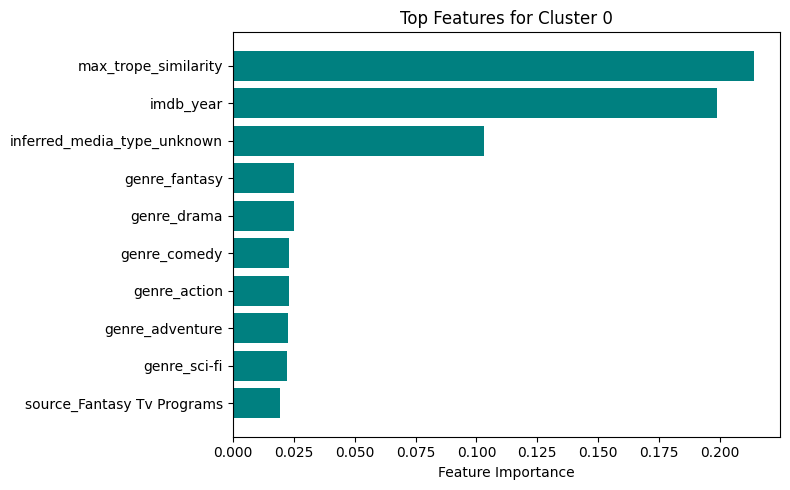

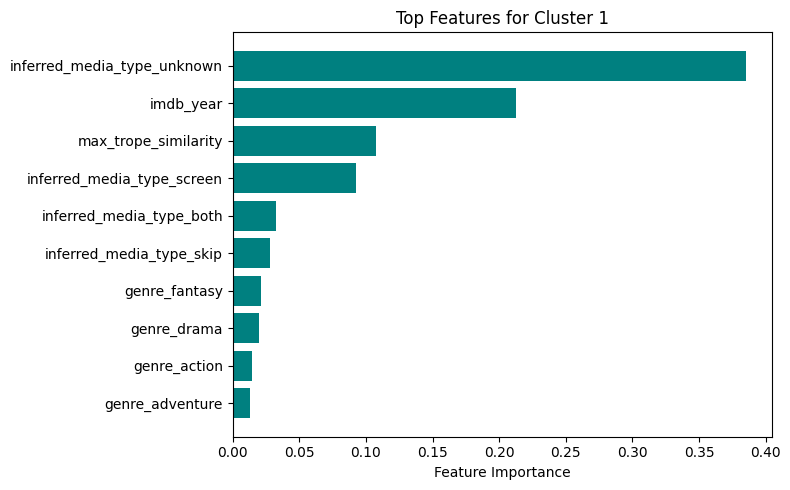

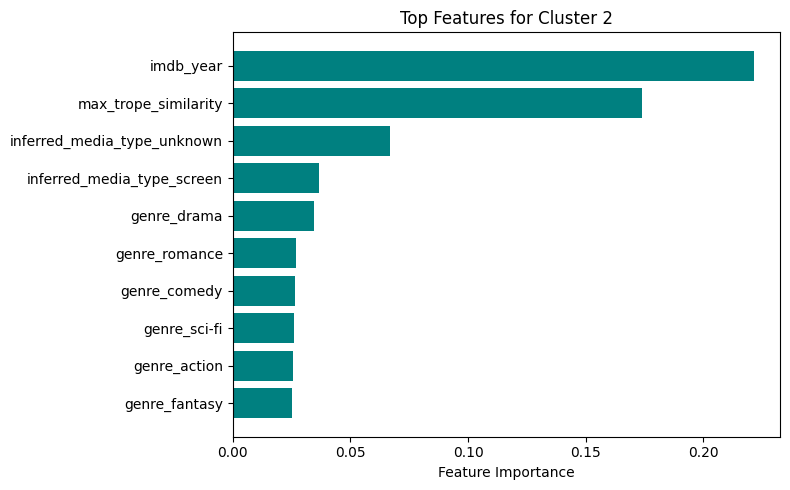

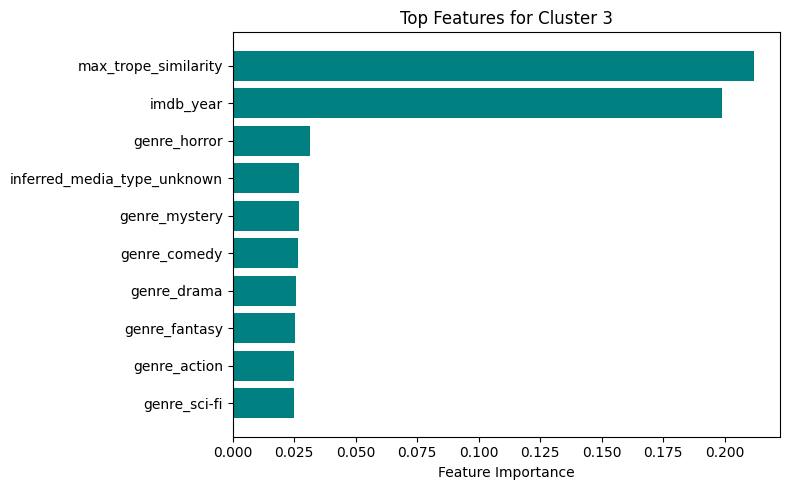

In [14]:
for idx, estimator in enumerate(ovr_rf.estimators_):
    importances = estimator.feature_importances_
    top_indices = np.argsort(importances)[::-1][:10]
    
    top_features = [feature_names[i] for i in top_indices]
    top_importances = importances[top_indices]
    
    plt.figure(figsize=(8, 5))
    plt.barh(top_features[::-1], top_importances[::-1], color='teal')
    plt.xlabel("Feature Importance")
    plt.title(f"Top Features for Cluster {idx}")
    plt.tight_layout()
    plt.show()

In [15]:
X_encoded = X_encoded.drop(columns=[col for col in X_encoded.columns if col.startswith('source_')])

In [16]:
scores = cross_val_score(ovr_rf, X_encoded, y, cv=cv, scoring='f1_macro')
print(f"Cross-validated Macro F1 Score: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

Cross-validated Macro F1 Score: 0.6710 ± 0.0187


In [ ]:

param_grid = {
    'estimator__n_estimators': [100, 200],
    'estimator__max_depth': [None, 10, 20],
    'estimator__max_features': ['sqrt', 'log2'],
    'estimator__min_samples_split': [2, 5],
    'estimator__min_samples_leaf': [1, 2],
}

grid_search = GridSearchCV(
    estimator=ovr_rf,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    verbose=2,
    n_jobs=-1
)


grid_search.fit(X_encoded, y)

print("Best parameters:", grid_search.best_params_)
print("Best Macro F1:", grid_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'estimator__max_depth': None, 'estimator__max_features': 'log2', 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 200}
Best Macro F1: 0.6580344097157755


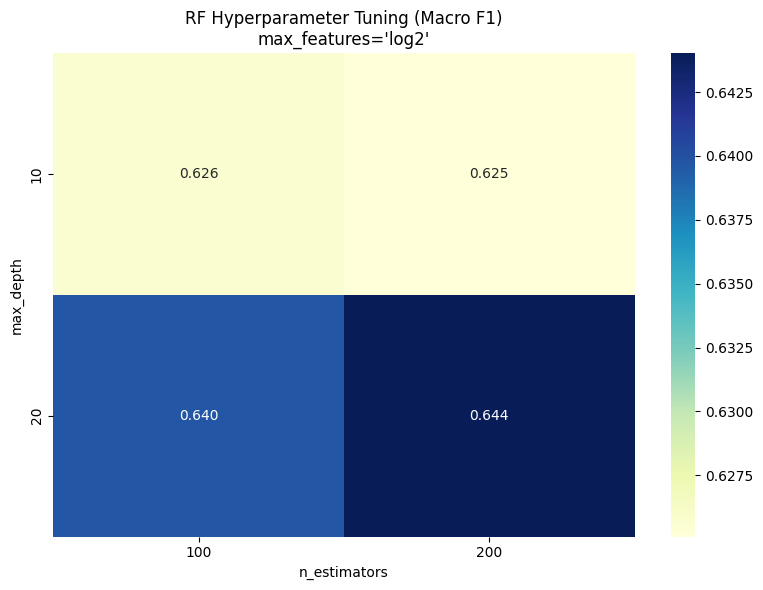

In [ ]:
cv_results = grid_search.cv_results_
cv_results_df = pd.DataFrame(cv_results)

filtered = cv_results_df[cv_results_df['param_estimator__max_features'] == 'log2']


heatmap_data = filtered.pivot_table(
    index='param_estimator__max_depth',
    columns='param_estimator__n_estimators',
    values='mean_test_score'
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)
plt.title("RF Hyperparameter Tuning (Macro F1)\nmax_features='log2'")
plt.xlabel("n_estimators")
plt.ylabel("max_depth")
plt.tight_layout()
plt.show()

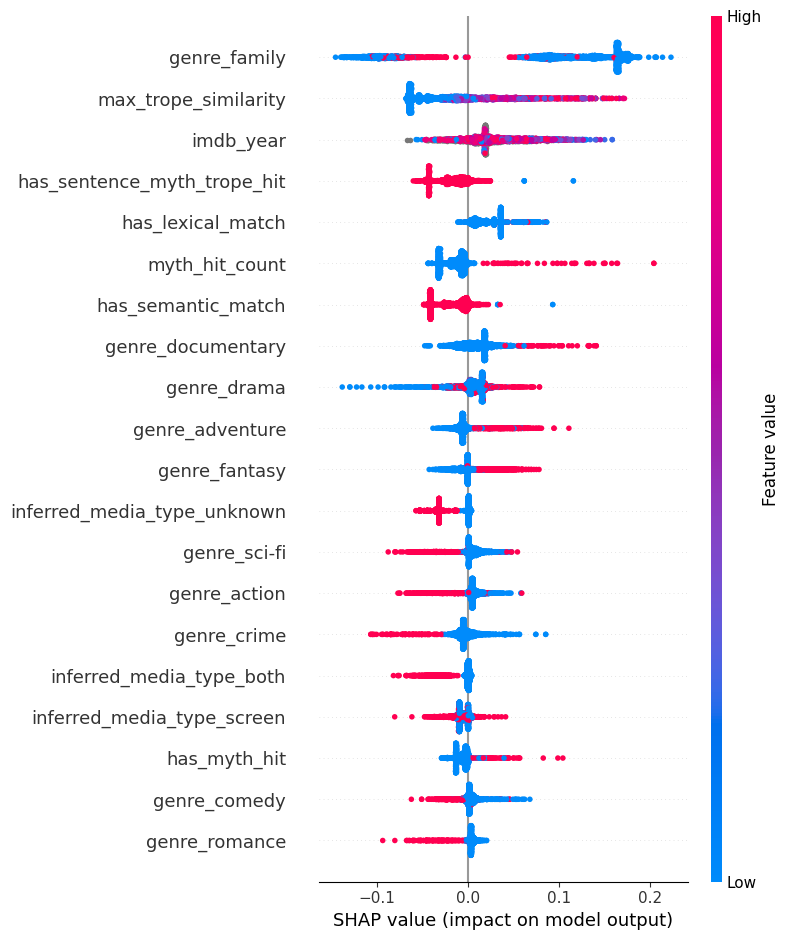

In [ ]:


X_encoded = X_encoded.astype(float)

cluster_idx = 0
rf_estimator = ovr_rf.estimators_[cluster_idx]


explainer = shap.TreeExplainer(rf_estimator)

shap_values = explainer.shap_values(X_encoded, check_additivity=False)


if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

shap.summary_plot(shap_values, X_encoded, feature_names=X_encoded.columns)


In [ ]:
X_encoded = X_encoded.astype(float)

for idx, rf_estimator in enumerate(ovr_rf.estimators_):
    print(f"Generating SHAP summary for Cluster {idx}...")

    explainer = shap.TreeExplainer(rf_estimator)
    

    shap_values = explainer.shap_values(X_encoded)

    if shap_values.ndim == 3:
        shap_values_cluster = shap_values[:, :, 1]
    else:
        shap_values_cluster = shap_values
    
    shap.summary_plot(
        shap_values_cluster,
        X_encoded,
        feature_names=X_encoded.columns,
        show=True
    )
    

Generating SHAP summary for Cluster 0...


ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. Consider retrying with the feature_perturbation='interventional' option. This check failed because for one of the samples the sum of the SHAP values was 0.141459, while the model output was 0.540000. If this difference is acceptable you can set check_additivity=False to disable this check.